In [1]:
from models import VGG11_32, VDP_VGG11_32
from utils_vdp import gaussian_loss, dirichlet_loss, mc_nll
from layers import MySoftmax

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix, balanced_accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from copy import deepcopy
from tqdm import tqdm
import torch.nn.functional as F


In [2]:
testset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True,
                                       transform=transforms.ToTensor())
trainloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True,
                                       transform=transforms.ToTensor())
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False, num_workers=2)


In [12]:
def dirichlet_loss(mu, sigma, targets, eps=1e-8, lambda_reg=0.01):
    """
    mu: [B, C] - predicted mean logits
    sigma: [B, C] - predicted variance logits (uncertainty)
    targets: [B] - ground truth labels
    lambda_reg: regularization weight
    """
    # Convert logits to probabilities
    #p = F.softmax(mu, dim=1)  # [B, C]
    
    # Better evidence calculation - inversely related to uncertainty
    evidence = mu / (sigma + eps)  # [B, C]
    
    # Dirichlet concentration parameters 
    alpha = evidence + 1  # avoid zero concentration
    
    # Compute alpha_0 (sum of all alpha parameters)
    alpha_0 = torch.sum(alpha, dim=1)  # [B]
    
    # Get target alphas
    target_oh = F.one_hot(targets, num_classes=mu.size(1)).float()  # [B, C]
    alpha_target = torch.sum(alpha * target_oh, dim=1)  # [B]
    
    # Main loss term - simplified approximation of Dirichlet negative log-likelihood
    main_loss = torch.log(alpha_0) - torch.log(alpha_target)
    
    # Regularization term to encourage low uncertainty for predicted class
    reg_loss = lambda_reg * torch.sum(mu * sigma, dim=1)

    # Total loss
    loss = main_loss + reg_loss
    
    return loss.mean()

def train_nn(model, trainloader, testloader, vdp=None, kl_factor=0.00001, lr=0.0001, epochs=15, device='cpu'):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    for _ in tqdm(range(epochs)):  # You can increase this
        model.train()
        running_loss = 0.0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            if not vdp:
                outputs = model(images)
                loss = criterion(outputs, labels)                
            elif vdp=="gaussian":
                mu, sigma, kl = model(images)
                mu, sigma = MySoftmax()(mu, sigma)
                loss = gaussian_loss(mu, sigma, labels) + kl_factor * kl
            elif vdp=="dirichlet":
                mu, sigma, kl = model(images)
                mu, sigma = MySoftmax()(mu, sigma)
                loss = dirichlet_loss(mu, sigma, labels) + kl_factor * kl
            elif vdp=="mc":
                mu, sigma, kl = model(images)
                loss = mc_nll(mu, sigma, labels) + kl_factor * kl
            
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        # Print average loss for each epoch
        print(f'Epoch {_+1}, Loss: {running_loss / len(trainloader)}')
    
    # Evaluation phase after training
    model.eval()

    correct = 0
    total = 0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)
        if not vdp:
            outputs = model(images)
        else:
            outputs, _, _ = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    accuracy_train = correct / total
    
    correct = 0
    total = 0
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        if not vdp:
            outputs = model(images)
        else:
            outputs, _, _ = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    accuracy_test = correct / total
    print(f"finished training with train acc {accuracy_train}, and test acc {accuracy_test}")
    return model, accuracy_test, accuracy_train
    

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = VGG11_32(num_classes=10).to(device)
model_vdp = VDP_VGG11_32(num_classes=10)
model_vdp(torch.zeros((1,3,32,32)))
model_vdp = model_vdp.to(device)

In [14]:

model, accuracy_test, accuracy_train = train_nn(deepcopy(model), trainloader, testloader, vdp=None, device=device)
model_gaus, accuracy_test_gaus, accuracy_train_gaus = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="gaussian", device=device)
model_diri, accuracy_test_diri, accuracy_train_diri = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="dirichlet", device=device)
model_mc, accuracy_test_mc, accuracy_train_mc = train_nn(deepcopy(model_vdp), trainloader, testloader, vdp="mc", device=device)

  7%|▋         | 1/15 [00:17<04:11, 17.98s/it]

Epoch 1, Loss: 2.1832674378934116


 13%|█▎        | 2/15 [00:36<03:55, 18.12s/it]

Epoch 2, Loss: 2.0759049745471887


 20%|██        | 3/15 [00:54<03:39, 18.29s/it]

...

100%|██████████| 15/15 [05:55<00:00, 23.72s/it]

Epoch 15, Loss: 1.745865498967183


finished training with train acc 0.80358, and test acc 0.7126


  0%|          | 0/15 [00:00<?, ?it/s]


RuntimeError: The size of tensor a (128) must match the size of tensor b (10) at non-singleton dimension 1

In [24]:
model_vdp = VDP_VGG11_32(num_classes=10)
model_vdp(next(iter(testloader))[0])
model_vdp.load_weights(model)

Parameters assigned successfully.


In [26]:
# Train from scratch
EPOCHS = 10
kl_factor = 0.00001
from layers import MySoftmax

model2 = VDP_VGG11_32(num_classes=10)
model2(next(iter(testloader))[0])

optimizer = optim.Adam(list(model2.parameters())[1::2], lr=0.0001)
model2_finetune = model2.to(device)

for epoch in range(EPOCHS):
    print(epoch)
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        mu, sigma, kl = model2_finetune(images)
        mu, sigma = MySoftmax()(mu, sigma) 

        loss1 = gaussian_loss(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum()
    running_loss /= len(trainloader)
    running_kl /= len(trainloader)
    accuracy /= len(trainloader.dataset)
    print(running_loss)

0
-0.09979351292232852
1
-0.09984276971749
2
-0.09988820760905205
3
-0.09993182227865711
4
-0.09997560858010529
5
-0.10001732802784837
6
-0.10005657829053409
7
-0.10009464330680377
8
-0.10012826856013175
9
-0.10016550564461642


In [33]:
import evaluate_models
ood = torchvision.datasets.SVHN(root='./data', download=True, transform=transforms.ToTensor())
oodloader = torch.utils.data.DataLoader(ood, batch_size=128, shuffle=False, num_workers=2)
evaluate_models.compare_two_models(model, model2_finetune, testloader, oodloader, 'cuda')

100.0%


Evaluating models
Evaluating VDP model
Evaluating calibration
Evaluating Gaussian noise
{'max_output_auroc': np.float64(0.6345767448844479), 'max_output_aupr': np.float64(0.242843816335356), 'max_output_fpr95': np.float64(0.9123087213508607), 'entropy_auroc': np.float64(0.5834690896433106), 'entropy_aupr': np.float64(0.2397117151821324), 'entropy_fpr95': np.float64(0.9573556110678842)} {'max_output_auroc': np.float64(0.7612051449008286), 'max_output_aupr': np.float64(0.23196815464041884), 'max_output_fpr95': np.float64(0.5882850785590455), 'mean_output_sigma_auroc': np.float64(0.5197679730264684), 'mean_output_sigma_aupr': np.float64(0.14356466621526187), 'mean_output_sigma_fpr95': np.float64(0.9365794395074873), 'max_output_sigma_auroc': np.float64(0.7612386365808046), 'max_output_sigma_aupr': np.float64(0.2320008558019686), 'max_output_sigma_fpr95': np.float64(0.5954243280505617), 'entropy_auroc': np.float64(0.7703091998034317), 'entropy_aupr': np.float64(0.2425206066566208), 'entrop

In [ ]:
a = {'max_output_auroc': np.float64(0.525561795), 'max_output_aupr': np.float64(0.5350241578011485), 'max_output_fpr95': np.float64(0.9452), 'entropy_auroc': np.float64(0.529439325), 'entropy_aupr': np.float64(0.5443236272765949), 'entropy_fpr95': np.float64(0.948)} 
b = {'max_output_auroc': np.float64(0.507251515), 'max_output_aupr': np.float64(0.4836343137405609), 'max_output_fpr95': np.float64(0.9371), 'mean_output_sigma_auroc': np.float64(0.5026941550000001), 'mean_output_sigma_aupr': np.float64(0.5154312651544586), 'mean_output_sigma_fpr95': np.float64(0.9994), 'max_output_sigma_auroc': np.float64(0.507202375), 'max_output_sigma_aupr': np.float64(0.4835300423827953), 'max_output_sigma_fpr95': np.float64(0.9401), 'entropy_auroc': np.float64(0.51020635), 'entropy_aupr': np.float64(0.4857942255353012), 'entropy_fpr95': np.float64(0.944), 'mean_logits_sigma_auroc': np.float64(0.5085502500000001), 'mean_logits_sigma_aupr': np.float64(0.503276590214477), 'mean_logits_sigma_fpr95': np.float64(0.9494), 'max_logits_sigma_auroc': np.float64(0.510072095), 'max_logits_sigma_aupr': np.float64(0.5048004154243882), 'max_logits_sigma_fpr95': np.float64(0.9457), 'full_mc_auroc': np.float64(0.5010918200000001), 'full_mc_aupr': np.float64(0.504963041220448), 'full_mc_fpr95': np.float64(0.9539), 'epistemic_mc_auroc': np.float64(0.50249126), 'epistemic_mc_aupr': np.float64(0.5044949213078905), 'epistemic_mc_fpr95': np.float64(0.9479), 'aleatoric_mc_auroc': np.float64(0.502572095), 'aleatoric_mc_aupr': np.float64(0.5042105974336617), 'aleatoric_mc_fpr95': np.float64(0.9485)} 

In [ ]:
{'max_output_auroc': np.float64(0.6345767448844479), 'max_output_aupr': np.float64(0.242843816335356), 'max_output_fpr95': np.float64(0.9123087213508607), 'entropy_auroc': np.float64(0.5834690896433106), 'entropy_aupr': np.float64(0.2397117151821324), 'entropy_fpr95': np.float64(0.9573556110678842)} {'max_output_auroc': np.float64(0.7612051449008286), 'max_output_aupr': np.float64(0.23196815464041884), 'max_output_fpr95': np.float64(0.5882850785590455), 'mean_output_sigma_auroc': np.float64(0.5197679730264684), 'mean_output_sigma_aupr': np.float64(0.14356466621526187), 'mean_output_sigma_fpr95': np.float64(0.9365794395074873), 'max_output_sigma_auroc': np.float64(0.7612386365808046), 'max_output_sigma_aupr': np.float64(0.2320008558019686), 'max_output_sigma_fpr95': np.float64(0.5954243280505617), 'entropy_auroc': np.float64(0.7703091998034317), 'entropy_aupr': np.float64(0.2425206066566208), 'entropy_fpr95': np.float64(0.5976084196732053), 'mean_logits_sigma_auroc': np.float64(0.5319120138689818), 'mean_logits_sigma_aupr': np.float64(0.13798380075761413), 'mean_logits_sigma_fpr95': np.float64(0.9643720054056267), 'max_logits_sigma_auroc': np.float64(0.5393133700533735), 'max_logits_sigma_aupr': np.float64(0.14100275378533614), 'max_logits_sigma_fpr95': np.float64(0.9591847878018482), 'full_mc_auroc': np.float64(0.5004980650313281), 'full_mc_aupr': np.float64(0.12099382466544614), 'full_mc_fpr95': np.float64(0.952277598045238), 'epistemic_mc_auroc': np.float64(0.5006419058929522), 'epistemic_mc_aupr': np.float64(0.12172152501328166), 'epistemic_mc_fpr95': np.float64(0.9469129229971197), 'aleatoric_mc_auroc': np.float64(0.5007985475790709), 'aleatoric_mc_aupr': np.float64(0.12174196571543118), 'aleatoric_mc_fpr95': np.float64(0.9468856218518367)} 

In [ ]:
# Train from scratch
EPOCHS = 15
kl_factor = 0.00001


model_dirichlet = VDP_VGG11_32(num_classes=10)
model_dirichlet(next(iter(testloader))[0])

optimizer = optim.Adam(list(model_dirichlet.parameters()), lr=0.0001)
model_dirichlet = model_dirichlet.to(device)

for epoch in range(EPOCHS):
    print(epoch)
    running_loss, running_kl, accuracy = 0.0, 0.0, 0.0
    for i, (images, labels) in enumerate(trainloader):
        images = images.to(device)
        labels = labels.to(device)
        # Forward pass
        mu, sigma, kl = model_dirichlet(images)
        mu, sigma = MySoftmax()(mu, sigma) 

        loss1 = dirichlet_loss(mu, sigma, labels)
        loss = loss1 + kl_factor * kl
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_kl += kl.item()
        accuracy += (mu.argmax(dim=1) == labels).float().sum()
    running_loss /= len(trainloader)
    running_kl /= len(trainloader)
    accuracy /= len(trainloader.dataset)
    print(running_loss, running_kl, accuracy)

KeyboardInterrupt: 

Balanced Accuracy: 0.4423
Macro F1 Score: 0.42541950107037485
              precision    recall  f1-score   support

           0       0.43      0.84      0.57      1000
           1       0.98      0.16      0.27      1000
           2       0.72      0.25      0.37      1000
           3       0.23      0.79      0.35      1000
           4       0.48      0.48      0.48      1000
           5       0.53      0.40      0.46      1000
           6       0.90      0.19      0.32      1000
           7       0.84      0.37      0.52      1000
           8       0.53      0.76      0.63      1000
           9       0.83      0.18      0.30      1000

    accuracy                           0.44     10000
   macro avg       0.65      0.44      0.43     10000
weighted avg       0.65      0.44      0.43     10000



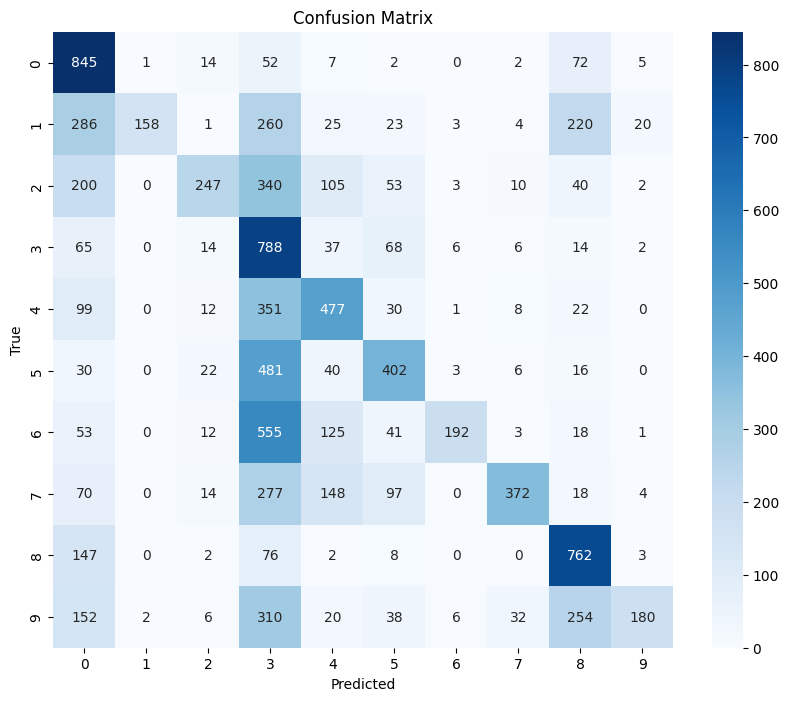

In [11]:
model.eval()
y_true = []
y_pred = []

for images, labels in testloader:
    images, labels = images.to(device), labels.to(device)
    outputs,_, _ = model2_finetune(images)
    _, preds = torch.max(outputs, 1)
    y_true.extend(labels.cpu().numpy())
    y_pred.extend(preds.cpu().numpy())

from sklearn.metrics import f1_score

print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()

Balanced Accuracy: 0.3465
Macro F1 Score: 0.30746573226296314
              precision    recall  f1-score   support

           0       0.47      0.36      0.41      1000
           1       0.91      0.09      0.16      1000
           2       0.31      0.39      0.35      1000
           3       0.23      0.69      0.35      1000
           4       0.36      0.31      0.33      1000
           5       0.45      0.33      0.38      1000
           6       0.80      0.18      0.29      1000
           7       0.95      0.16      0.28      1000
           8       0.32      0.92      0.47      1000
           9       0.90      0.03      0.05      1000

    accuracy                           0.35     10000
   macro avg       0.57      0.35      0.31     10000
weighted avg       0.57      0.35      0.31     10000



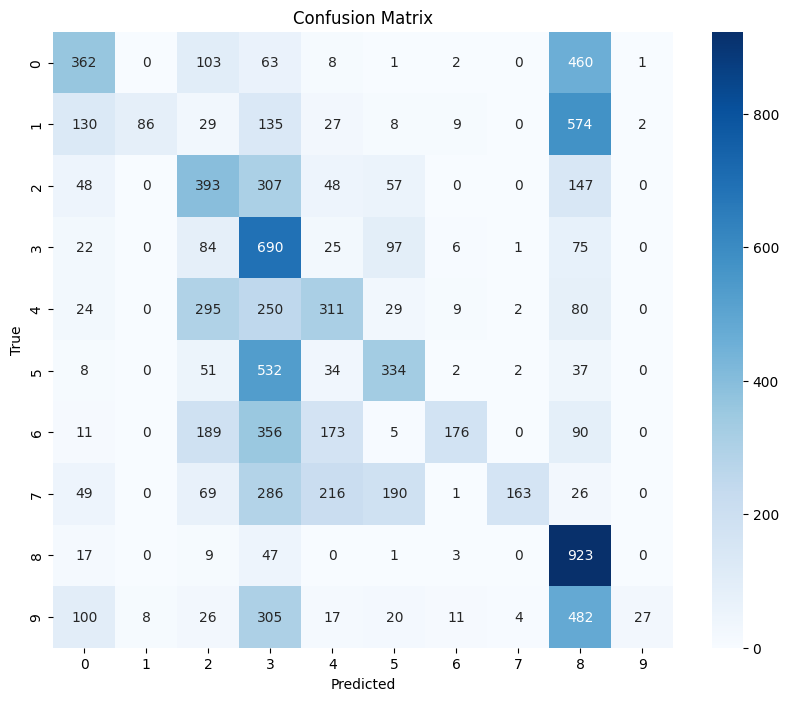

In [12]:
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        y_true.extend(labels.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

from sklearn.metrics import f1_score

print("Balanced Accuracy:", balanced_accuracy_score(y_true, y_pred))
print("Macro F1 Score:", f1_score(y_true, y_pred, average='macro'))

# Classification Report
print(classification_report(y_true, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=list(range(10)), yticklabels=list(range(10)))
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [16]:
from collections import defaultdict
import torch.nn.functional as F

def fgsm_attack(model, images, labels, epsilon, vdp=True):
    images.requires_grad = True
    if vdp:
        outputs, _, _ = model(images)
    else:
        outputs = model(images)
    loss = F.cross_entropy(outputs, labels)
    model.zero_grad()
    loss.backward()
    data_grad = images.grad.data
    perturbed = images + epsilon * data_grad.sign()
    return torch.clamp(perturbed, 0, 1)

def pgd_attack(model, images, labels, epsilon=0.03, alpha=0.007, num_iter=10, vdp=True):
    images = images.clone().detach().to(device)
    labels = labels.to(device)
    ori_images = images.clone().detach()

    for _ in range(num_iter):
        images.requires_grad = True
        if vdp:
            outputs, _, _ = model(images)
        else:
            outputs = model(images)
        loss = F.cross_entropy(outputs, labels)
        model.zero_grad()
        loss.backward()
        grad = images.grad.data

        # Update
        adv_images = images + alpha * grad.sign()
        # Project back into epsilon-ball
        eta = torch.clamp(adv_images - ori_images, min=-epsilon, max=epsilon)
        images = torch.clamp(ori_images + eta, min=0, max=1).detach()

    return images

def evaluate_classwise_accuracy(model, dataloader, epsilon=0.0, attack_type="clean", alpha=0.007, num_iter=10, vdp=True):
    model.eval()
    correct_per_class = defaultdict(int)
    total_per_class = defaultdict(int)


    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)
        if attack_type == "fgsm":
            images = fgsm_attack(model, images, labels, epsilon, vdp=vdp)
        elif attack_type == "pgd":
            images = pgd_attack(model, images, labels, epsilon, alpha, num_iter, vdp=vdp)

        if vdp:
            outputs, _, _ = model(images)
        else:
            outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for label, pred in zip(labels, preds):
            total_per_class[label.item()] += 1
            if pred.item() == label.item():
                correct_per_class[label.item()] += 1

    acc = {c: correct_per_class[c] / total_per_class[c] for c in total_per_class}
    return acc


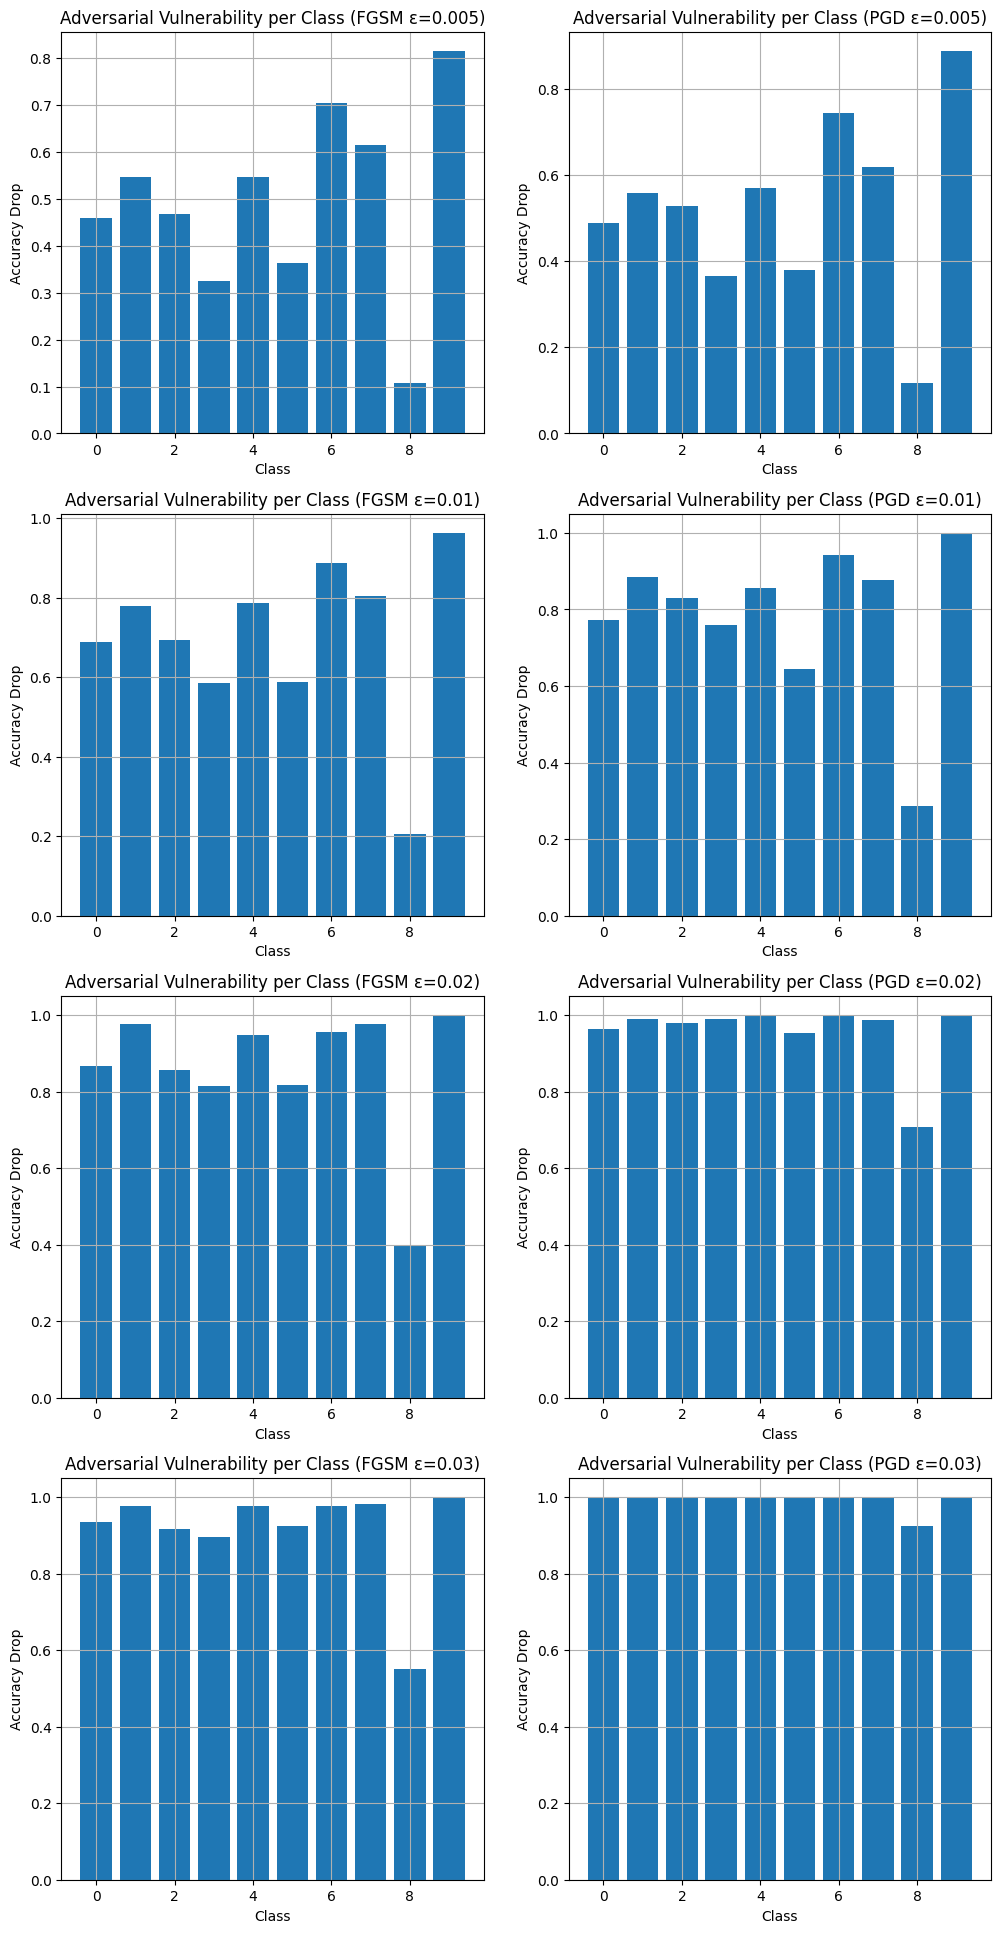

In [18]:
epsilons = [0.005, 0.01, 0.02, 0.03]
fig, axs = plt.subplots(len(epsilons), 2, figsize=(12,6*len(epsilons)))

for idx, epsilon in enumerate(epsilons):
    clean_acc = evaluate_classwise_accuracy(model, testloader, attack_type="clean", vdp=False)
    fgsm_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="fgsm", vdp=False)
    pgd_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="pgd", vdp=False)


    fgsm_drops = {c: (clean_acc[c] - fgsm_acc[c])/(clean_acc[c]+1e-9) for c in clean_acc}
    pgd_drops = {c: (clean_acc[c] - pgd_acc[c])/(clean_acc[c]+1e-9) for c in clean_acc}


    axs[idx, 0].bar(fgsm_drops.keys(), fgsm_drops.values())
    axs[idx, 0].set_xlabel("Class")
    axs[idx, 0].set_ylabel("Accuracy Drop")
    axs[idx, 0].set_title(f"Adversarial Vulnerability per Class (FGSM ε={epsilon})")
    axs[idx, 0].grid(True)

    axs[idx, 1].bar(pgd_drops.keys(), pgd_drops.values())
    axs[idx, 1].set_xlabel("Class")
    axs[idx, 1].set_ylabel("Accuracy Drop")
    axs[idx, 1].set_title(f"Adversarial Vulnerability per Class (PGD ε={epsilon})")
    axs[idx, 1].grid(True)



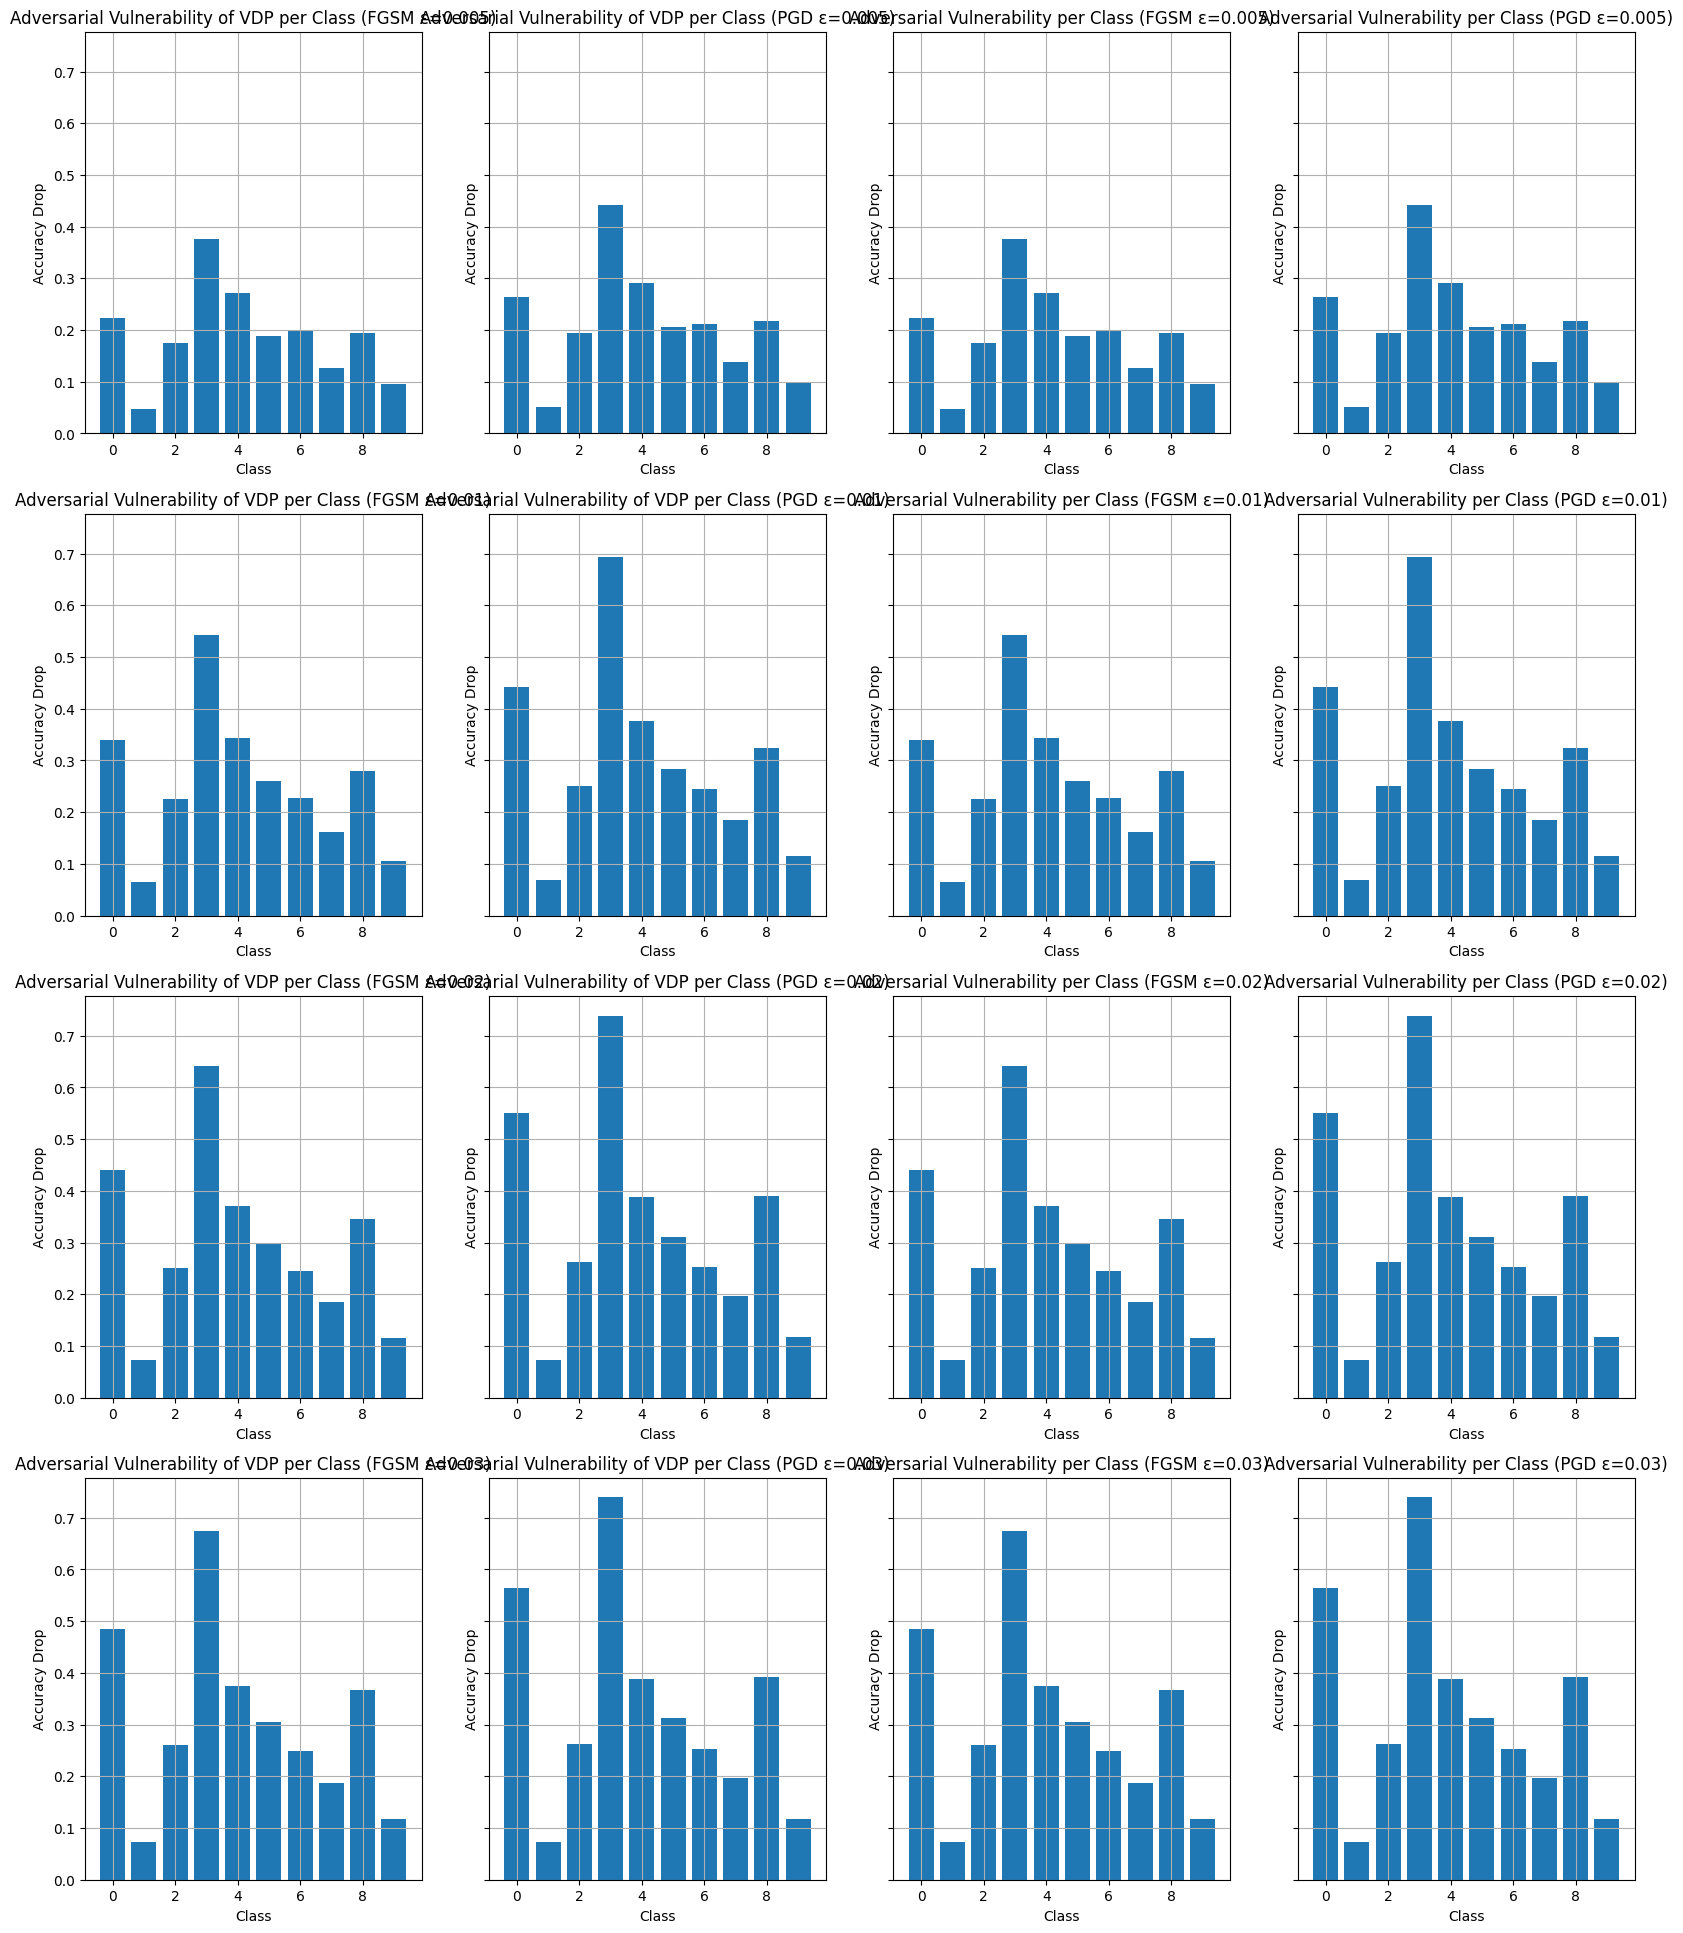

In [29]:
epsilons = [0.005, 0.01, 0.02, 0.03]
fig, axs = plt.subplots(len(epsilons), 4, figsize=(20,6*len(epsilons)), sharey=True)

for idx, epsilon in enumerate(epsilons):
    clean_acc_vdp = evaluate_classwise_accuracy(model2, testloader, attack_type="clean", vdp=True)
    fgsm_acc_vdp = evaluate_classwise_accuracy(model2, testloader, epsilon=epsilon, attack_type="fgsm", vdp=True)
    pgd_acc_vdp = evaluate_classwise_accuracy(model2, testloader, epsilon=epsilon, attack_type="pgd", vdp=True)

    clean_acc = evaluate_classwise_accuracy(model, testloader, attack_type="clean", vdp=False)
    fgsm_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="fgsm", vdp=False)
    pgd_acc = evaluate_classwise_accuracy(model, testloader, epsilon=epsilon, attack_type="pgd", vdp=False)


    fgsm_drops_vdp = {c: (clean_acc_vdp[c] - fgsm_acc_vdp[c]) for c in clean_acc_vdp}
    pgd_drops_vdp = {c: (clean_acc_vdp[c] - pgd_acc_vdp[c]) for c in clean_acc_vdp}


    fgsm_drops = {c: (clean_acc[c] - fgsm_acc[c]) for c in clean_acc}
    pgd_drops = {c: (clean_acc[c] - pgd_acc[c]) for c in clean_acc}


    axs[idx, 0].bar(fgsm_drops_vdp.keys(), fgsm_drops.values())
    axs[idx, 0].set_xlabel("Class")
    axs[idx, 0].set_ylabel("Accuracy Drop")
    axs[idx, 0].set_title(f"Adversarial Vulnerability of VDP per Class (FGSM ε={epsilon})")
    axs[idx, 0].grid(True)

    axs[idx, 1].bar(pgd_drops_vdp.keys(), pgd_drops.values())
    axs[idx, 1].set_xlabel("Class")
    axs[idx, 1].set_ylabel("Accuracy Drop")
    axs[idx, 1].set_title(f"Adversarial Vulnerability of VDP per Class (PGD ε={epsilon})")
    axs[idx, 1].grid(True)

    axs[idx, 2].bar(fgsm_drops.keys(), fgsm_drops.values())
    axs[idx, 2].set_xlabel("Class")
    axs[idx, 2].set_ylabel("Accuracy Drop")
    axs[idx, 2].set_title(f"Adversarial Vulnerability per Class (FGSM ε={epsilon})")
    axs[idx, 2].grid(True)

    axs[idx, 3].bar(pgd_drops.keys(), pgd_drops.values())
    axs[idx, 3].set_xlabel("Class")
    axs[idx, 3].set_ylabel("Accuracy Drop")
    axs[idx, 3].set_title(f"Adversarial Vulnerability per Class (PGD ε={epsilon})")
    axs[idx, 3].grid(True)


In [24]:

from collections import Counter

label_counts = Counter([label for _, label in trainset])
sorted_classes = sorted(label_counts.items(), key=lambda x: x[1], reverse=True)
head_classes = [c for c, _ in sorted_classes[:5]]  # e.g., top 5
tail_classes = [c for c, _ in sorted_classes[-5:]]  # bottom 5

head_acc = np.mean([class_acc[c] for c in head_classes])
tail_acc = np.mean([class_acc[c] for c in tail_classes])
print(f"Head class adversarial accuracy: {head_acc:.3f}")
print(f"Tail class adversarial accuracy: {tail_acc:.3f}")

# Assume you have clean_acc and adv_acc dictionaries
drops = {c: clean_acc[c] - adv_acc[c] for c in clean_acc}
plt.bar(drops.keys(), drops.values())
plt.xlabel("Class")
plt.ylabel("Accuracy Drop")
plt.title("Adversarial Vulnerability per Class")
plt.grid(True)
plt.show()




Head class adversarial accuracy: 0.103
Tail class adversarial accuracy: 0.064
